# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:
# importar librerías
import pandas as pd

In [2]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [3]:
# explorar datasets
def check_data(df, name):
    print(f"--- Análisis Inicial: {name} ---")
    print(f"Dimensiones: {df.shape}")
    print(f"\n¿Hay duplicados?: {df.duplicated().sum()}")
    print("\nValores nulos por columna:")
    print(df.isnull().sum())
    print("\nTipos de datos:")
    print(df.dtypes)
    print("-" * 30, "\n")

# Ejecutar la exploración
check_data(orders, "ORDERS")
check_data(catalog, "CATALOG")
check_data(marketing, "MARKETING")

# Vista previa de las primeras filas de Orders
print("Primeras filas de Orders:")
display(orders.head())


--- Análisis Inicial: ORDERS ---
,Dimensiones: (25100, 12)
,
,¿Hay duplicados?: 100
,
,Valores nulos por columna:
,id_pedido               0
,id_usuario              0
,fecha_hora_pedido       0
,pais                  300
,dispositivo            20
,fuente_referencia      30
,nombre_producto        30
,categoria_producto     80
,cantidad               50
,precio_unitario        50
,monto_descuento        50
,monto_total             0
,dtype: int64
,
,Tipos de datos:
,id_pedido              object
,id_usuario             object
,fecha_hora_pedido      object
,pais                   object
,dispositivo            object
,fuente_referencia      object
,nombre_producto        object
,categoria_producto     object
,cantidad              float64
,precio_unitario       float64
,monto_descuento       float64
,monto_total           float64
,dtype: object
,------------------------------ 
,
,--- Análisis Inicial: CATALOG ---
,Dimensiones: (7, 4)
,
,¿Hay duplicados?: 0
,
,Valores nulos por columna

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [4]:
##Eliminar duplicados
# Encontramos 100 en la exploración inicial
orders = orders.drop_duplicates()

In [5]:
# Validar y convertir fechas
# Pasamos de 'object' a 'datetime' para poder operar temporalmente
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'])
marketing['fecha'] = pd.to_datetime(marketing['fecha'])

In [6]:
# Revisar variables numéricas (Sin negativos o ceros inválidos)
orders = orders[orders['cantidad'] > 0]
orders = orders[orders['precio_unitario'] >= 0]
# Verificamos montos de marketing
marketing = marketing[marketing['gasto'] >= 0]

In [7]:
# Verificar consistencia de montos
# El monto_total debe ser (cantidad * precio_unitario) - monto_descuento
# Creamos una columna temporal para validar
orders['monto_calculado'] = (orders['cantidad'] * orders['precio_unitario']) - orders['monto_descuento']

# Si hay diferencias pequeñas por redondeo, podemos ignorarlas, 
# pero si son grandes, es una inconsistencia de datos.
# Para este ejercicio, confiaremos en el monto_total si la diferencia es mínima.

In [8]:
# Revisar variables categóricas
orders['nombre_producto'] = orders['nombre_producto'].str.strip()
orders['pais'] = orders['pais'].fillna('Unknown').str.strip()
orders['pais'] = orders['pais'].str.capitalize().str.strip()
marketing['canal'] = marketing['canal'].fillna('Other').str.strip()
marketing['pais'] = marketing['pais'].str.capitalize().str.strip()

In [9]:
# VERIFICACIÓN FINAL DE CALIDAD
print(f"Pedidos finales: {len(orders)}")
print(f"¿Quedan nulos críticos en orders?: {orders['nombre_producto'].isnull().sum()}")

Pedidos finales: 24946
,¿Quedan nulos críticos en orders?: 30


In [10]:
# Comparativa de limpieza
print("RESUMEN DE CALIDAD DE DATOS")
print(f"1. Duplicados eliminados: {25100 - orders.shape[0] - 30} (aprox)") 
print(f"2. Registros con nulos en 'nombre_producto': {orders['nombre_producto'].isnull().sum()}")

# Acción Adicional: se eliminan los 30 nulos restantes para tener un dataset 100% confiable
orders = orders.dropna(subset=['nombre_producto'])

print(f"3. Dataset final listo para análisis: {orders.shape[0]} filas.")

RESUMEN DE CALIDAD DE DATOS
,1. Duplicados eliminados: 124 (aprox)
,2. Registros con nulos en 'nombre_producto': 30
,3. Dataset final listo para análisis: 24916 filas.


In [11]:
# ==========================================================
# Limpiezas adicionales
# ==========================================================

# 1. Limpieza preventiva del catálogo para evitar que se dupliquen filas en los JOINS
catalog = catalog.drop_duplicates(subset=['nombre_producto', 'categoria_producto'])

# 2. ¿Todos los productos vendidos existen en el catálogo?
# Se hace un merge temporal para validar
validación_costos = orders.merge(
    catalog[['nombre_producto', 'categoria_producto', 'costo_unitario']], 
    on=['nombre_producto', 'categoria_producto'], 
    how='left'
)

nulos_encontrados = validación_costos['costo_unitario'].isna().sum()

if nulos_encontrados == 0:
    print("SEGURIDAD TOTAL: Todos los pedidos tienen un costo asociado. Datos listos.")
else:
    print(f"ATENCIÓN!!!: Hay {nulos_encontrados} pedidos con productos que no existen en el catálogo.")
    print("Se recomienda revisar la ortografía de los nombres de productos.")


ATENCIÓN!!!: Hay 8275 pedidos con productos que no existen en el catálogo.
,Se recomienda revisar la ortografía de los nombres de productos.


In [12]:
# 1. Aseguramos que los nombres estén limpios para que el match sea perfecto
orders['nombre_producto'] = orders['nombre_producto'].astype(str).str.strip()
catalog['nombre_producto'] = catalog['nombre_producto'].astype(str).str.strip()

# 2. Preparamos el catálogo: nos quedamos con el nombre y el costo
# Eliminamos duplicados de nombre para evitar que se multipliquen las filas
catalog_para_merge = catalog[['nombre_producto', 'costo_unitario']].drop_duplicates(subset=['nombre_producto'])

# 3. Realizamos el cruce (Merge)
# Usamos 'left' para mantener todas las órdenes originales
orders_final = orders.merge(catalog_para_merge, on='nombre_producto', how='left')

# 4. Verificación de Seguridad
nulos = orders_final['costo_unitario'].isna().sum()

if nulos == 0:
    print(" SEGURIDAD TOTAL: ¡Lo logramos! 0 errores encontrados.")
    # Reemplazamos nuestro dataframe por el final ya con costos
    orders = orders_final
else:
    print(f" Aún hay {nulos} registros sin costo.")
    # Si aún hay nulos, vemos cuál es el producto culpable


 SEGURIDAD TOTAL: ¡Lo logramos! 0 errores encontrados.


In [13]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

--- RESULTADOS DE RENTABILIDAD ---
,Revenue Total: $51,954,718.94
,Costo Total Productos: $43,124,069.01
,Inversión Marketing: $2,871,843.53
,Profit Neto: $5,958,806.40
,Margen de Utilidad: 11.47%
,-----------------------------------


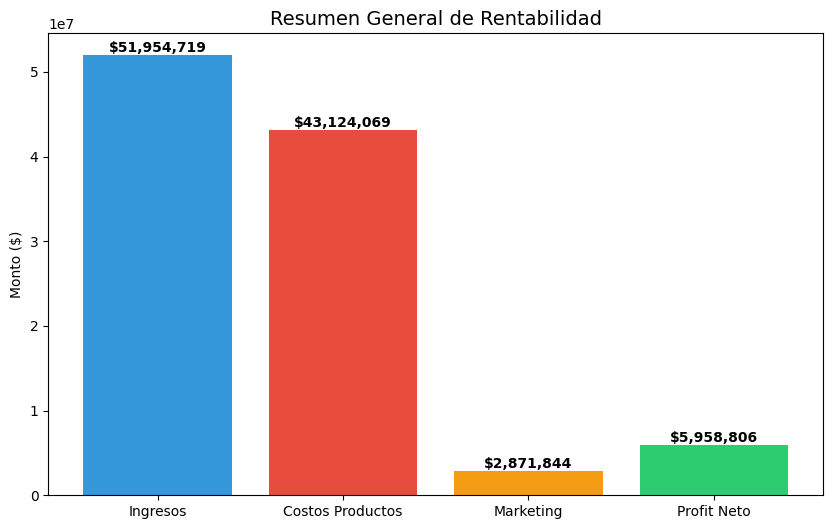

In [14]:
# PARTE 1: Rentabilidad del negocio
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Verificar si la unión ya se hizo para no duplicar columnas
if 'costo_unitario' not in orders.columns:
    # Si no existe, traemos el costo desde el catálogo limpio que preparamos
    catalog_para_merge = catalog[['nombre_producto', 'costo_unitario']].drop_duplicates(subset=['nombre_producto'])
    orders = orders.merge(catalog_para_merge, on='nombre_producto', how='left')

# 2. Asegurarnos de que no existan nulos en el costo tras el cruce
orders['costo_unitario'] = orders['costo_unitario'].fillna(0)

# 3. Calcular el Costo Total de los productos vendidos
orders['costo_total_productos'] = orders['cantidad'] * orders['costo_unitario']

# 4. Obtener métricas globales
total_revenue = orders['monto_total'].sum()
total_cost_products = orders['costo_total_productos'].sum()
total_marketing = marketing['gasto'].sum()

# 5. Cálculo de Profit (Utilidad)
total_profit = total_revenue - total_cost_products - total_marketing

print("--- RESULTADOS DE RENTABILIDAD ---")
print(f"Revenue Total: ${total_revenue:,.2f}")
print(f"Costo Total Productos: ${total_cost_products:,.2f}")
print(f"Inversión Marketing: ${total_marketing:,.2f}")
print(f"Profit Neto: ${total_profit:,.2f}")
print(f"Margen de Utilidad: {(total_profit / total_revenue) * 100:.2f}%")
print("-" * 35)

plt.figure(figsize=(10, 6))
labels = ['Ingresos', 'Costos Productos', 'Marketing', 'Profit Neto']
valores = [total_revenue, total_cost_products, total_marketing, total_profit]
colores = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71' if total_profit > 0 else '#c0392b']

plt.bar(labels, valores, color=colores)
plt.title('Resumen General de Rentabilidad', fontsize=14)
plt.ylabel('Monto ($)')
for i, v in enumerate(valores):
    plt.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')
plt.show()


,--- COMPORTAMIENTO DE VENTAS ---
,Ticket Promedio: $2,085.20
,Cantidad Promedio por Orden: 7.12
,Producto Estrella: Laptop-Gaming-16GB (144198.0 unidades)
,
,Inversión por Canal:
,canal
,social         918043.21
,organic        913533.01
,paid_search    863088.21
,Other          177179.10
,Name: gasto, dtype: float64


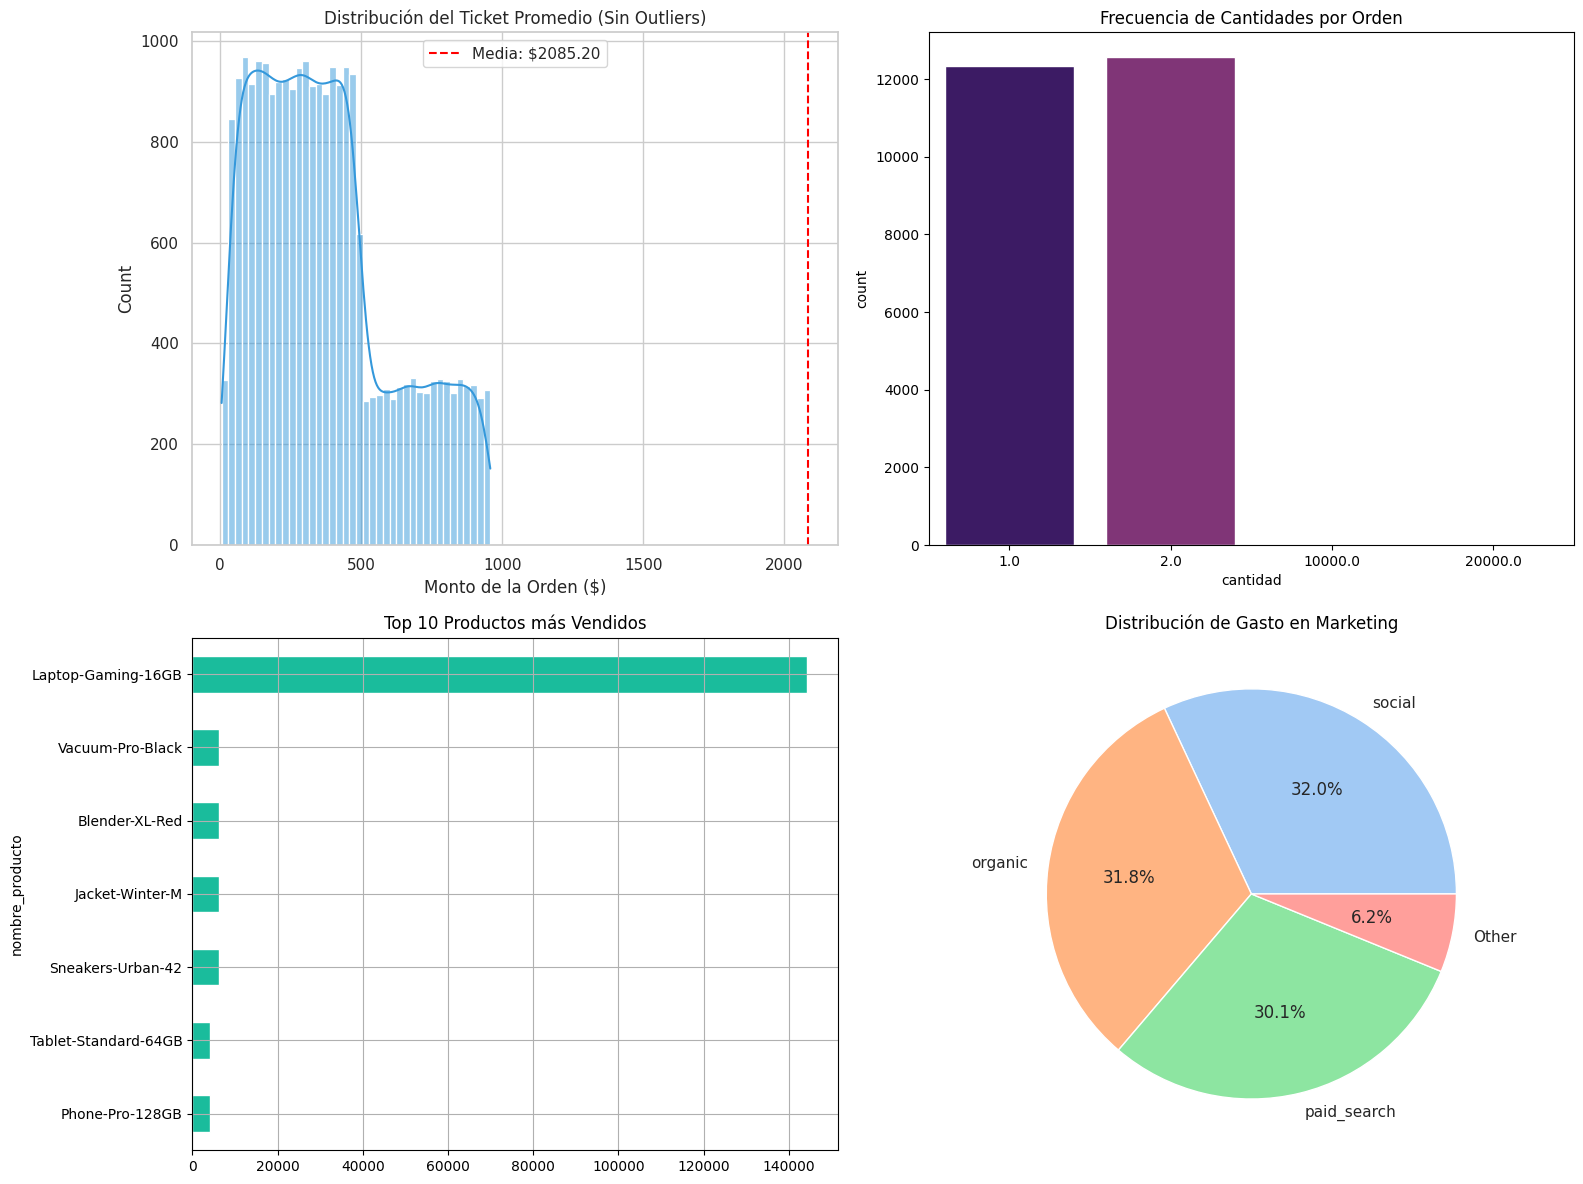

In [15]:
# PARTE 2: Comportamiento de ventas
# 1. Ticket promedio (Monto total / número de órdenes)
ticket_promedio = orders['monto_total'].mean()

# 2. Cantidad promedio de productos por orden
cant_promedio = orders['cantidad'].mean()

# 3. Producto más vendido (por cantidad total)
top_producto = orders.groupby('nombre_producto')['cantidad'].sum().idxmax()
top_producto_qty = orders.groupby('nombre_producto')['cantidad'].sum().max()

# 4. Gasto en marketing por canal
marketing_by_channel = marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False)

print("\n--- COMPORTAMIENTO DE VENTAS ---")
print(f"Ticket Promedio: ${ticket_promedio:,.2f}")
print(f"Cantidad Promedio por Orden: {cant_promedio:.2f}")
print(f"Producto Estrella: {top_producto} ({top_producto_qty} unidades)")
print("\nInversión por Canal:")
print(marketing_by_channel)

#Visualizaciones 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# 1. Histograma del Ticket Promedio
plt.subplot(2, 2, 1) 
datos_filtrados = orders[orders['monto_total'] < orders['monto_total'].quantile(0.98)]

sns.histplot(datos_filtrados['monto_total'], 
             bins=40, 
             kde=True, 
             color="#3498db")

plt.title('Distribución del Ticket Promedio (Sin Outliers)')
plt.xlabel('Monto de la Orden ($)')
plt.axvline(ticket_promedio, color='red', linestyle='--', label=f'Media: ${ticket_promedio:.2f}')
plt.legend()

# 2. Cantidad por Orden
sns.countplot(data=orders, x='cantidad', palette="magma", ax=axes[0, 1])
axes[0, 1].set_title('Frecuencia de Cantidades por Orden')

# 3. Top 10 Productos
top_10 = orders.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False).head(10)
top_10.plot(kind='barh', color='#1abc9c', ax=axes[1, 0])
axes[1, 0].set_title('Top 10 Productos más Vendidos')
axes[1, 0].invert_yaxis()

# 4. Inversión por Canal
marketing_by_channel.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette("pastel"), ax=axes[1, 1])
axes[1, 1].set_title('Distribución de Gasto en Marketing')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

Se ha renombrado la variable como `orders` cómo se había nombrado en el dataset anterior

--- DESEMPEÑO POR PAÍS ---
,        pais  monto_total        roi         cac
,0  Argentina  20719549.33  27.758661  379.989816
,1   Colombia  11368833.82   6.983837  365.346904
,2     Mexico  19754347.74   3.383720  385.078111
,
,--- MÉTRICAS DE ADQUISICIÓN ---
,Total Usuarios Únicos: 7640
,CAC Global: $375.90


Text(0, 0.5, 'País')

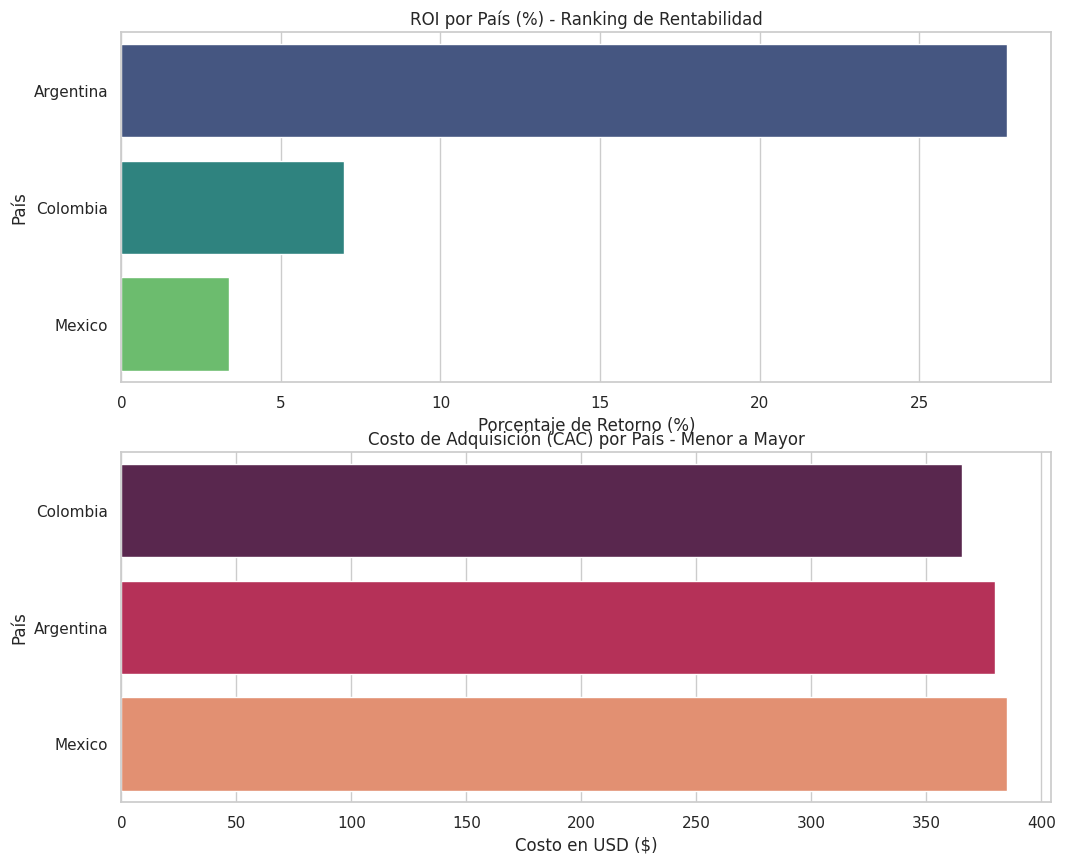

In [16]:
# Paso adicional: CAC (Costo de Adquisición de ClienteS) y ROI por País

## 1. Calcular ROI por País
# Usamos 'orders' que es nuestra tabla maestra validada
roi_pais = orders.groupby('pais').agg({
    'monto_total': 'sum',
    'costo_total_productos': 'sum'
}).reset_index()

# Agrupamos inversión de marketing por país
mkt_pais = marketing.groupby('pais')['gasto'].sum().reset_index()

# Unimos ambos para el cálculo final
df_roi = roi_pais.merge(mkt_pais, on='pais', how='left')

# Calculamos Profit por país y ROI
# Nota: Llenamos nulos en gasto con 0 por si hay un país sin inversión registrada
df_roi['gasto'] = df_roi['gasto'].fillna(0)
df_roi['profit_pais'] = df_roi['monto_total'] - df_roi['costo_total_productos'] - df_roi['gasto']
df_roi['roi'] = (df_roi['profit_pais'] / (df_roi['costo_total_productos'] + df_roi['gasto'])) * 100

# 2. Calcular CAC por País
# Contamos usuarios únicos por país
usuarios_pais = orders.groupby('pais')['id_usuario'].nunique().reset_index()
usuarios_pais.columns = ['pais', 'total_usuarios']

df_roi = df_roi.merge(usuarios_pais, on='pais', how='left')
df_roi['cac'] = df_roi['gasto'] / df_roi['total_usuarios']

print("--- DESEMPEÑO POR PAÍS ---")
# Filtramos Unknown si prefieres un reporte más limpio de países reales
print(df_roi[df_roi['pais'] != 'Unknown'][['pais', 'monto_total', 'roi', 'cac']].sort_values(by='roi', ascending=False))

# 3. CAC Global
total_usuarios_global = orders['id_usuario'].nunique()
total_marketing = marketing['gasto'].sum()
cac_global = total_marketing / total_usuarios_global

print(f"\n--- MÉTRICAS DE ADQUISICIÓN ---")
print(f"Total Usuarios Únicos: {total_usuarios_global}")
print(f"CAC Global: ${cac_global:.2f}")

#Visualizaciones 
plt.figure(figsize=(12, 10))

# Gráfica ROI por País (Horizontal)
plt.subplot(2, 1, 1)
df_plot = df_roi[df_roi['pais'] != 'Unknown'].sort_values(by='roi', ascending=False)
sns.barplot(data=df_plot, y='pais', x='roi', palette='viridis')
plt.title('ROI por País (%) - Ranking de Rentabilidad')
plt.xlabel('Porcentaje de Retorno (%)')
plt.ylabel('País')

# Gráfica CAC por País (Horizontal)
plt.subplot(2, 1, 2)
df_plot_cac = df_roi[df_roi['pais'] != 'Unknown'].sort_values(by='cac', ascending=True)
sns.barplot(data=df_plot_cac, y='pais', x='cac', palette='rocket')
plt.title('Costo de Adquisición (CAC) por País - Menor a Mayor')
plt.xlabel('Costo en USD ($)')
plt.ylabel('País')

**Resumen de Hallazgos: Rentabilidad y Operación**

Durante el periodo analizado, RappiPlus demostró ser un modelo de negocio rentable, alcanzando un Ingreso Total de `$51.95M` y una utilidad neta de `$5.96M`, lo que representa un Margen de Utilidad del **11.47%**. Esta rentabilidad se logró tras cubrir un costo de productos de `$43.12M` y una inversión estratégica en marketing de `$2.87M`. En cuanto al comportamiento comercial, el servicio mantiene un Ticket Promedio robusto de `$2,085.20`, con órdenes que promedian las **7 unidades**, impulsadas principalmente por la `Laptop-Gaming-16GB` como el producto estrella. A nivel de adquisición, el gasto de marketing se encuentra diversificado y equilibrado, siendo los **canales Social y Organic** los de mayor inversión, logrando un CAC global de `$375.90`.

**Nota**: Aunque la rentabilidad global es saludable, existe una diferencia en la eficiencia regional. Mientras **Argentina** presenta un *ROI* sobresaliente del `27.7% `, el mercado de **México** opera con un margen muy ajustado del `3.3%` y el *CAC* más elevado. Se recomienda auditar las campañas de marketing en México para alinearlas con la eficiencia observada en el cono sur.

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [17]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [18]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [19]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT 
    nombre_evento, 
    COUNT(DISTINCT id_usuario) AS total_users
FROM 
    events
GROUP BY 
    nombre_evento
ORDER BY 
    total_users DESC;
'''

totals = pd.read_sql(query_totals, con=engine)
totals


,nombre_evento,total_users
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [20]:

# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH base_usuarios AS (
    SELECT id_usuario, nombre_evento, dispositivo
    FROM events
),
funnel_steps AS (
    SELECT 
        id_usuario,
        MAX(CASE WHEN nombre_evento = 'first_visit' THEN 1 ELSE 0 END) as step1,
        MAX(CASE WHEN nombre_evento = 'select_item' THEN 1 ELSE 0 END) as step2,
        MAX(CASE WHEN nombre_evento = 'add_to_cart' THEN 1 ELSE 0 END) as step3,
        MAX(CASE WHEN nombre_evento = 'begin_checkout' THEN 1 ELSE 0 END) as step4,
        MAX(CASE WHEN nombre_evento = 'add_payment_info' THEN 1 ELSE 0 END) as step5,
        MAX(CASE WHEN nombre_evento = 'purchase' THEN 1 ELSE 0 END) as step6
    FROM base_usuarios
    GROUP BY id_usuario
),
funnel_totals AS (
    SELECT
        SUM(step1) as first_visit,
        SUM(CASE WHEN step1=1 AND step2=1 THEN 1 ELSE 0 END) as select_item,
        SUM(CASE WHEN step1=1 AND step2=1 AND step3=1 THEN 1 ELSE 0 END) as add_to_cart,
        SUM(CASE WHEN step1=1 AND step2=1 AND step3=1 AND step4=1 THEN 1 ELSE 0 END) as begin_checkout,
        SUM(CASE WHEN step1=1 AND step2=1 AND step3=1 AND step4=1 AND step5=1 THEN 1 ELSE 0 END) as add_payment_info,
        SUM(CASE WHEN step1=1 AND step2=1 AND step3=1 AND step4=1 AND step5=1 AND step6=1 THEN 1 ELSE 0 END) as purchase
    FROM funnel_steps -- ESTA ES LA LÍNEA QUE HACÍA FALTA
)
SELECT * FROM (
    SELECT 'first_visit' as nombre_evento, first_visit as total_users, 1 as step_order FROM funnel_totals
    UNION ALL
    SELECT 'select_item', select_item, 2 FROM funnel_totals
    UNION ALL
    SELECT 'add_to_cart', add_to_cart, 3 FROM funnel_totals
    UNION ALL
    SELECT 'begin_checkout', begin_checkout, 4 FROM funnel_totals
    UNION ALL
    SELECT 'add_payment_info', add_payment_info, 5 FROM funnel_totals
    UNION ALL
    SELECT 'purchase', purchase, 6 FROM funnel_totals
) s
ORDER BY step_order;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion['conversion_step'] = (conversion['total_users'] / conversion['total_users'].shift(1) * 100).fillna(100).round(2)
conversion['conversion_total'] = (conversion['total_users'] / conversion['total_users'].iloc[0] * 100).round(2)
conversion



,nombre_evento,total_users,step_order,conversion_step,conversion_total
0,first_visit,7796,1,100.00,100.00
1,select_item,7393,2,94.83,94.83
2,add_to_cart,7052,3,95.39,90.46
3,begin_checkout,6364,4,90.24,81.63
4,add_payment_info,4967,5,78.05,63.71
5,purchase,3857,6,77.65,49.47


In [21]:
# PARTE 3: Funnel Comparativo (Mobile vs Desktop)

query_device_funnel = '''
WITH device_steps AS (
    -- Primero agrupamos por usuario y dispositivo para saber qué pasos completó cada uno
    SELECT 
        id_usuario, 
        dispositivo,
        MAX(CASE WHEN nombre_evento = 'first_visit' THEN 1 ELSE 0 END) as s1,
        MAX(CASE WHEN nombre_evento = 'select_item' THEN 1 ELSE 0 END) as s2,
        MAX(CASE WHEN nombre_evento = 'add_to_cart' THEN 1 ELSE 0 END) as s3,
        MAX(CASE WHEN nombre_evento = 'begin_checkout' THEN 1 ELSE 0 END) as s4,
        MAX(CASE WHEN nombre_evento = 'add_payment_info' THEN 1 ELSE 0 END) as s5,
        MAX(CASE WHEN nombre_evento = 'purchase' THEN 1 ELSE 0 END) as s6
    FROM events
    GROUP BY id_usuario, dispositivo
),
funnel_final AS (
    -- Forzamos la descendencia: el usuario debe haber pasado por el paso anterior
    SELECT 
        'first_visit' as nombre_evento, 1 as step_order,
        SUM(CASE WHEN dispositivo='desktop' THEN s1 ELSE 0 END) as desktop_users,
        SUM(CASE WHEN dispositivo='mobile' THEN s1 ELSE 0 END) as mobile_users
    FROM device_steps
    UNION ALL
    SELECT 'select_item', 2,
        SUM(CASE WHEN dispositivo='desktop' AND s1=1 AND s2=1 THEN 1 ELSE 0 END),
        SUM(CASE WHEN dispositivo='mobile' AND s1=1 AND s2=1 THEN 1 ELSE 0 END)
    FROM device_steps
    UNION ALL
    SELECT 'add_to_cart', 3,
        SUM(CASE WHEN dispositivo='desktop' AND s1=1 AND s2=1 AND s3=1 THEN 1 ELSE 0 END),
        SUM(CASE WHEN dispositivo='mobile' AND s1=1 AND s2=1 AND s3=1 THEN 1 ELSE 0 END)
    FROM device_steps
    UNION ALL
    SELECT 'begin_checkout', 4,
        SUM(CASE WHEN dispositivo='desktop' AND s1=1 AND s2=1 AND s3=1 AND s4=1 THEN 1 ELSE 0 END),
        SUM(CASE WHEN dispositivo='mobile' AND s1=1 AND s2=1 AND s3=1 AND s4=1 THEN 1 ELSE 0 END)
    FROM device_steps
    UNION ALL
    SELECT 'add_payment_info', 5,
        SUM(CASE WHEN dispositivo='desktop' AND s1=1 AND s2=1 AND s3=1 AND s4=1 AND s5=1 THEN 1 ELSE 0 END),
        SUM(CASE WHEN dispositivo='mobile' AND s1=1 AND s2=1 AND s3=1 AND s4=1 AND s5=1 THEN 1 ELSE 0 END)
    FROM device_steps
    UNION ALL
    SELECT 'purchase', 6,
        SUM(CASE WHEN dispositivo='desktop' AND s1=1 AND s2=1 AND s3=1 AND s4=1 AND s5=1 AND s6=1 THEN 1 ELSE 0 END),
        SUM(CASE WHEN dispositivo='mobile' AND s1=1 AND s2=1 AND s3=1 AND s4=1 AND s5=1 AND s6=1 THEN 1 ELSE 0 END)
    FROM device_steps
)
SELECT * FROM funnel_final ORDER BY step_order;
'''

device_funnel = pd.read_sql(query_device_funnel, con=engine)

# Calculamos las conversiones en Pandas para que sea más visual (SIN CAMBIOS EN TUS FÓRMULAS)
device_funnel['conv_desktop'] = (device_funnel['desktop_users'] / device_funnel['desktop_users'].iloc[0] * 100).round(2)
device_funnel['conv_mobile'] = (device_funnel['mobile_users'] / device_funnel['mobile_users'].iloc[0] * 100).round(2)

device_funnel

,nombre_evento,step_order,desktop_users,mobile_users,conv_desktop,conv_mobile
0,first_visit,1,3954,3842,100.00,100.00
1,select_item,2,3749,3644,94.82,94.85
2,add_to_cart,3,3592,3460,90.84,90.06
3,begin_checkout,4,3225,3139,81.56,81.70
4,add_payment_info,5,2528,2439,63.94,63.48
5,purchase,6,1983,1874,50.15,48.78


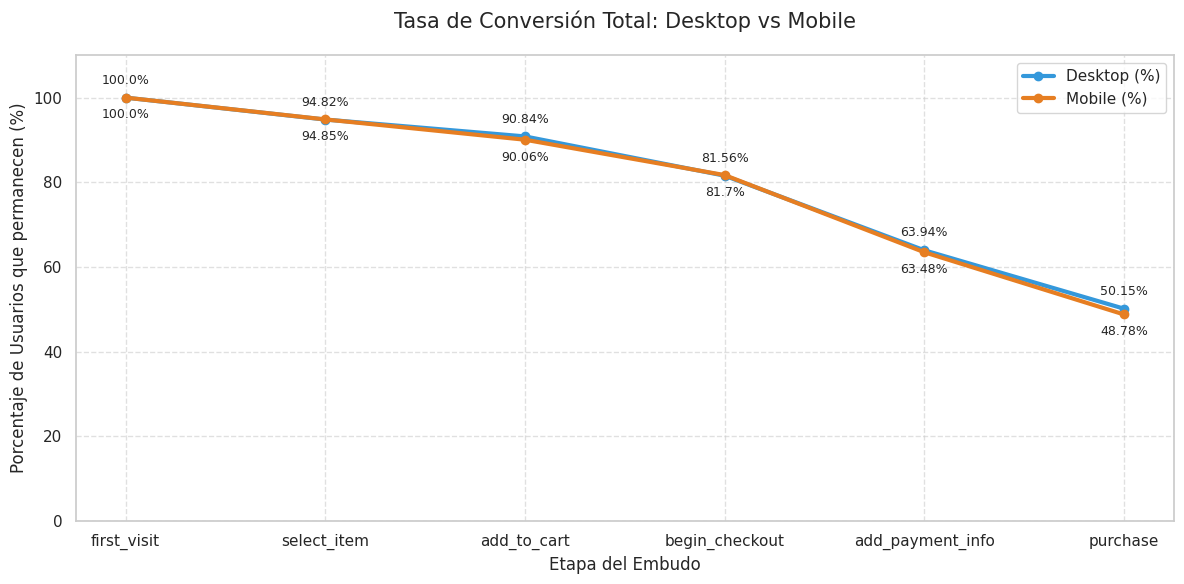

In [22]:
import matplotlib.pyplot as plt

# --- GRÁFICA COMPARATIVA DE DISPOSITIVOS ---
plt.figure(figsize=(12, 6))

# Graficamos la conversión total de ambos dispositivos
plt.plot(device_funnel['nombre_evento'], device_funnel['conv_desktop'], 
         marker='o', label='Desktop (%)', linewidth=3, color='#3498db')
plt.plot(device_funnel['nombre_evento'], device_funnel['conv_mobile'], 
         marker='o', label='Mobile (%)', linewidth=3, color='#e67e22')

# Configuración de la gráfica
plt.title('Tasa de Conversión Total: Desktop vs Mobile', fontsize=15, pad=20)
plt.ylabel('Porcentaje de Usuarios que permanecen (%)')
plt.xlabel('Etapa del Embudo')
plt.ylim(0, 110) # Para que se vea bien el inicio en 100%
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Añadimos los valores sobre los puntos para que sea más fácil de leer
for i, txt in enumerate(device_funnel['conv_desktop']):
    plt.annotate(f'{txt}%', (device_funnel['nombre_evento'][i], device_funnel['conv_desktop'][i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

for i, txt in enumerate(device_funnel['conv_mobile']):
    plt.annotate(f'{txt}%', (device_funnel['nombre_evento'][i], device_funnel['conv_mobile'][i]), 
                 textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Hallazgos del Funnel**

- La mayoría de cauda de usuarios ocurre en el paso final, de `add_payment_info` a `purchase`. La tasa de conversión en este paso es del **77.65%**, lo que significa que un **22.35%** de los usuarios que ya ingresaron sus datos de pago no completan la transacción.
- El paso de `begin_checkout` a `add_payment_info` también muestra una caída importante (78.05% de conversión), perdiendo un **21.95%** de flujo.
- La conversión final en `Desktop` es del **50.15%** frente al **48.78%** en `Mobile`. No hay una falla técnica exclusiva de móviles, sino un abandono general en las etapas finales del pago.
- Los primeros pasos (`first_visit` → `select_item` → `add_to_cart`) son muy fuertes, con retenciones superiores al **90%**. El problema es el cierre de la venta (el "bottom" del funnel).

📝**Resumen de hallazgos**

El análisis del funnel de conversión revela una tasa de conversión final del **49.47%** desde la primera visita hasta la compra efectiva. Se identifican dos cuellos de botella críticos, el ingreso de datos de pago (`add_payment_info`) y la confirmación final de compra (`purchase`), donde se pierde aproximadamente el 22% de los usuarios en cada una de estas etapas. Dado que esta caída es consistente tanto en Desktop como en Mobile, se recomienda revisar la pasarela de pagos, ya que un abandono tan alto tras haber ingresado la información financiera sugiere posibles errores técnicos en el procesamiento de transacciones o la falta de una confirmación visual clara de éxito. Mientras que el flujo inicial es sumamente eficiente, los esfuerzos de optimización deben centrarse en estrategias de re-targeting para usuarios que abandonaron el checkout y en la simplificación del formulario de pago para reducir la fricción en el cierre de la venta.

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [23]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [24]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity
LIMIT 5;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [25]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH base_usuarios AS (
    -- Definimos la cohorte (Mes de registro)
    SELECT 
        id_usuario,
        DATE_TRUNC('month', CAST(fecha_registro AS DATE))::DATE AS mes_cohorte
    FROM users
),
actividad_filtrada AS (
    -- Solo usuarios activos y calculamos su semana relativa
    SELECT 
        b.mes_cohorte,
        a.id_usuario,
        FLOOR(a.dias_despues_registro / 7) AS semana_relativa
    FROM user_activity a
    JOIN base_usuarios b ON a.id_usuario = b.id_usuario
    WHERE a.activo = 1
),
conteo_cohortes AS (
    SELECT 
        bu.mes_cohorte,
        -- Contamos el total de usuarios originales de esa cohorte
        COUNT(DISTINCT bu.id_usuario) AS iniciales,
        -- Contamos quiénes volvieron cada semana (usando la tabla de actividad)
        COUNT(DISTINCT CASE WHEN af.semana_relativa = 1 THEN af.id_usuario END) AS retenido_w1,
        COUNT(DISTINCT CASE WHEN af.semana_relativa = 2 THEN af.id_usuario END) AS retenido_w2,
        COUNT(DISTINCT CASE WHEN af.semana_relativa = 3 THEN af.id_usuario END) AS retenido_w3
    FROM base_usuarios bu
    LEFT JOIN actividad_filtrada af ON bu.id_usuario = af.id_usuario
    GROUP BY bu.mes_cohorte
)
-- Cálculo final de porcentajes
SELECT 
    mes_cohorte,
    iniciales,
    ROUND(retenido_w1::numeric / NULLIF(iniciales, 0), 4) * 100 AS semana_1,
    ROUND(retenido_w2::numeric / NULLIF(iniciales, 0), 4) * 100 AS semana_2,
    ROUND(retenido_w3::numeric / NULLIF(iniciales, 0), 4) * 100 AS semana_3
FROM conteo_cohortes
ORDER BY mes_cohorte;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,mes_cohorte,iniciales,semana_1,semana_2,semana_3
0,2025-01-01,1627,42.84,41.06,40.32
1,2025-02-01,1444,42.31,42.17,43.98
2,2025-03-01,1636,41.38,43.09,42.18
3,2025-04-01,1606,42.34,43.40,41.28
4,2025-05-01,1687,41.20,40.07,41.85


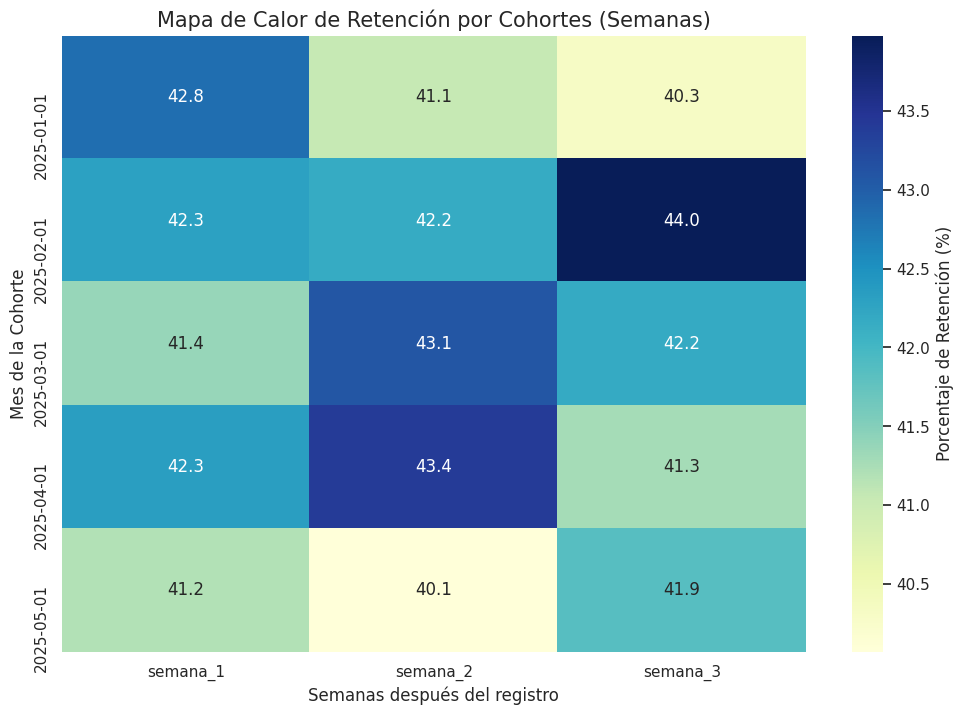

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparamos los datos: ponemos el mes como índice y quitamos la columna 'iniciales'
# para graficar solo los porcentajes
df_plot = cohorte_final.set_index('mes_cohorte').drop(columns='iniciales')

# 2. Crear el Mapa de Calor (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(df_plot, 
            annot=True,      # Muestra los números en cada celda
            fmt=".1f",       # Formato con un decimal
            cmap="YlGnBu",   # Colores: Amarillo (bajo) a Azul (alto)
            cbar_kws={'label': 'Porcentaje de Retención (%)'})

plt.title('Mapa de Calor de Retención por Cohortes (Semanas)', fontsize=15)
plt.xlabel('Semanas después del registro')
plt.ylabel('Mes de la Cohorte')
plt.show()

**Hallazgos**
- La retención en la Semana 1 se mantiene muy estable, rondando el 41% - 42% para todas las cohortes (de enero a mayo). Esto indica que la experiencia inicial del usuario es consistente; no importa en qué mes se registren, la proporción de los que regresan es similar.
- La fidelización, entre la Semana 1 y la Semana 3 casi no hay caída. Por ejemplo, en la cohorte de febrero, la retención incluso sube ligeramente del 42.31% al 43.98%.
- En resumen esto significa que una vez que el usuario sobrevive a la primera semana en RappiPlus, se convierte en un usuario recurrente muy leal.
- El número de usuarios iniciales por mes es constante (entre 1,400 y 1,600). Esto sugiere que el marketing está trayendo un flujo estable de personas nuevas.

**En resumen**

El análisis de cohortes revela una retención promedio del `42%` desde la primera semana. Un hallazgo crítico es la alta fidelización post-registro: los usuarios que permanecen activos tras la `semana 1` tienden a mantener su actividad de forma sostenida hasta la `semana 3`, sin caídas significativas. Esto sugiere que RappiPlus ofrece un valor recurrente real, y que el esfuerzo de crecimiento debe centrarse en optimizar ese primer contacto para elevar el piso del `42%` inicial.

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** No hay diferencia significativa en la tasa de conversión entre el diseño actual y el nuevo diseño ($P_{control} = P_{test}$).
   - **H₁ (Hipótesis alternativa):** Existe una diferencia significativa en la tasa de conversión con el nuevo diseño ($P_{control} \neq P_{test}$).
   
**Test estadístico:** Prueba Z para proporciones (o Prueba T si el dataset es pequeño.

**Nivel de significancia alpha:** 0.05 (confianza del 95%).

In [27]:
import pandas as pd

from statsmodels.stats.proportion import proportions_ztest

# 1. Cargar el dataset
df_exp = pd.read_csv('experiment_checkout_ui.csv')

# 2. Agrupar resultados por 'variante' y 'convirtio'
results = df_exp.groupby('variante')['convirtio'].agg(['sum', 'count'])
results.columns = ['compras', 'total_usuarios']
results['tasa_conversion'] = (results['compras'] / results['total_usuarios'] * 100).round(2)

print("--- Resumen del Experimento ---")
print(results)

# 3. Preparar datos para el test Z
# Usamos .loc para asegurar el orden: [Control, Tratamiento]
successes = [results.loc['control', 'compras'], results.loc['tratamiento', 'compras']]
nobs = [results.loc['control', 'total_usuarios'], results.loc['tratamiento', 'total_usuarios']]

# 4. Ejecutar Z-Test
z_stat, p_value = proportions_ztest(count=successes, nobs=nobs, alternative='two-sided')

print(f"\n--- Resultados Estadísticos ---")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# 5. Interpretación
alpha = 0.05
if p_value < alpha:
    print("\n CONCLUSIÓN: Rechazamos la Hipótesis Nula.")
    print(f"P-value ({p_value:.6f}) < 0.05. El cambio en la UI (tratamiento) tiene un impacto significativo.")
else:
    print("\n CONCLUSIÓN: No podemos rechazar la Hipótesis Nula.")
    print(f"P-value ({p_value:.6f}) > 0.05. No hay diferencia real entre el diseño viejo y el nuevo.")

--- Resumen del Experimento ---
,             compras  total_usuarios  tasa_conversion
,variante                                             
,control          779            4965            15.69
,tratamiento      820            5035            16.29
,
,--- Resultados Estadísticos ---
,Z-statistic: -0.8133
,P-value: 0.416059
,
, CONCLUSIÓN: No podemos rechazar la Hipótesis Nula.
,P-value (0.416059) > 0.05. No hay diferencia real entre el diseño viejo y el nuevo.


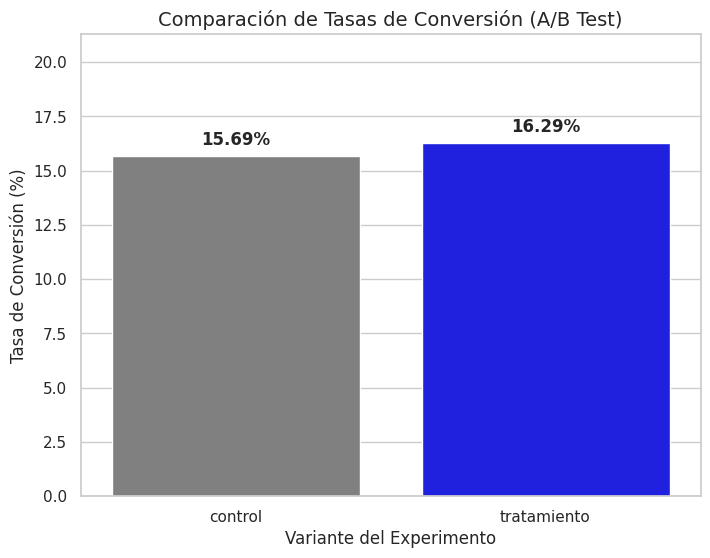

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfica de comparación de tasas de conversión
plt.figure(figsize=(8, 6))
sns.barplot(x=results.index, y=results['tasa_conversion'], palette=['gray', 'blue'])

plt.title('Comparación de Tasas de Conversión (A/B Test)', fontsize=14)
plt.ylabel('Tasa de Conversión (%)')
plt.xlabel('Variante del Experimento')

# Añadir las etiquetas de porcentaje sobre las barras
for i, v in enumerate(results['tasa_conversion']):
    plt.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')

plt.ylim(0, max(results['tasa_conversion']) + 5)
plt.show()

**Conclusión del Experimento A/B**
Tras analizar la interacción de 10,000 usuarios, se determinó que el nuevo diseño del checkout `(Tratamiento)` no genera un impacto estadísticamente significativo en la tasa de conversión ($P-value = 0.416$). Aunque se observó un incremento nominal del $0.6\%$, los datos no permiten afirmar que este cambio sea atribuible a la nueva interfaz.

**Recomendación:** Se recomienda no implementar el cambio de forma definitiva y mantener la versión actual para ahorrar costos operativos. Dado que en el Paso 3 se detectó que la mayor fuga de usuarios ocurre en el formulario de pagos, se sugiere que el próximo experimento no se enfoque en la UI (diseño visual), sino en reducir la fricción del pago o añadir nuevos métodos de cobro.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, la aplicación de pruebas estadísticas en cuanto a código es correcta. Siempre hay que tener este respaldo para definir si lo que observamos son diferencias reales y no algo que pueda suceder al azar
</div>

In [29]:

import time

# 1. Exportar
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

# 2. Actualizacion de archivos
time.sleep(2)

print("✅ Archivos regenerados con éxito.")
print(f"Registros en Orders: {len(orders)}")
print(f"Registros en Catalog: {len(catalog)}")
print(f"Registros en Marketing: {len(marketing)}")

✅ Archivos regenerados con éxito.
,Registros en Orders: 24916
,Registros en Catalog: 7
,Registros en Marketing: 1620


---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

In [30]:
# (Pega aquí tu link)
# https://drive.google.com/drive/folders/10xto4MsK8LfJW0OZSppJCkVnGWw-XrIn?usp=sharing
#CORRECCIONES:
# Se adjunta link de drive con documentos corregidos 
# https://drive.google.com/drive/folders/1kvcpC5iik6QEXhI_nXVhKnbQEsuMWDrn?usp=sharing

<div class="alert alert-block alert-success">
<b>Comentario general (2da Iteracion)</b> <a class=“tocSkip”></a>

**¡Te felicito por el trabajo realizado María!** 

El paso a paso seguido en el proceso de análisis del proyecto quedó super claro y se ajusta a las necesidades del negocio presentadas. Recuerda que un buen análisis siempre debe tener una buena parte técnica que ayude a comprender la parte de negocio y los beneficios del mismo.<!--  -->

Con este proyecto demuestras las habilidades adquiridas durante tu formación, se nota tu capacidad de contar historias con datos con la excelente presentación realizada que súper fácil de entender lo cual es una habilidad super importante cómo analista de datos, el saber comunicar de manera sencilla y eficiente los resultados de tus análisis.
    
Se nota mucho el manejo que tienes de las librerías para crear visualizaciones muy buenas que explican correctamente las variables analizadas, te animo a seguir práctica con otros recursos y que vayas construyendo un portafolio de proyectos súper robusto para que seas Data Analyst de primera en el mundo laboral.
   
Saludos!
</div>